# 第18章：终极优化 GEMM -- 所有技巧的组合

## 前置知识
- 第09章：分块矩阵乘法基础
- 第11章：Autotuning
- 第12章：Block Pointer 与 Shared Memory
- 第13章：软件流水线
- 第14章：Split-K 并行
- 第15章：L2 Cache Swizzle
- 第16章：混合精度策略
- 第17章：Tensor Core 深入

## 学习目标
- 将前面所有章节的优化技巧**组合**成一个终极 GEMM kernel
- 使用 **Autotuning** 在大配置空间中搜索最优参数
- 对多种矩阵尺寸 benchmark 并对比 cuBLAS
- 使用 **Roofline Model** 分析性能瓶颈
- 回顾从 naive 到 ultimate 的完整优化路径
- 总结 CUDA vs Triton 的性能对比

## 对应 CUDA 代码
- 贯穿整个项目: simt_naive → simt_regci → simt_smem → simt_smemT → simt_pipline
- Tensor Core 路径: wmma_naive → mma_naive → mma_ci → mma_smem → mma_ldmatrix → mma_pipline
- 本章的 Triton kernel 综合了以上所有优化

In [1]:
import torch
import triton
import triton.language as tl

## 18.1 优化技巧回顾

### 我们学过的所有优化技巧

```
优化层级:    技巧                    章节   CUDA 对应          Triton 实现
─────────────────────────────────────────────────────────────────────────────────
算法层面     分块 (Tiling)           Ch.09  simt_regci/smem   tl.load + tl.dot
             Split-K 并行           Ch.14  —                 atomic_add

内存层面     Shared Memory 优化     Ch.12  simt_smem          make_block_ptr
             软件流水线             Ch.13  simt_pipline       num_stages
             L2 Cache Swizzle       Ch.15  simt_smemT         pid 重映射

计算层面     Tensor Core 利用       Ch.17  wmma/mma           tl.dot
             混合精度               Ch.16  half/float acc     FP32 累加器

调参层面     Autotuning             Ch.11  手动调参           @triton.autotune
```

### 优化路径图

```
CUDA 优化路径 (本项目的 16 个 kernel):

SIMT 路径:
  simt_naive ──→ simt_regci ──→ simt_smem ──→ simt_smemT ──→ simt_pipline
  (逐元素)      (寄存器tiling) (共享内存)    (smem转置)     (流水线)
  
WMMA 路径:
  wmma_naive ──→ wmma_ci ──→ wmma_smem ──→ wmma_pipline
  (基础WMMA)    (计算强度)  (smem优化)    (流水线)

MMA 路径:
  mma_naive ──→ mma_ci ──→ mma_smem ──→ mma_ldmatrix ──→ mma_ldmatrix_trans ──→ mma_pipline
  (PTX基础)    (计算强度) (smem优化)   (ldmatrix)       (转置)                   (流水线)


Triton 优化路径 (本教程):

                                          ┌─→ splitk (Ch.14, tall-skinny 分支)
  naive ──→ blocked ──→ block_ptr ──→ pipeline ──┤
  (Ch.08)   (Ch.09)     (Ch.12)      (Ch.13)    └─→ swizzle (Ch.15, 大方阵分支)
                                                            ↓
                                                      autotuned (Ch.18)
                                                   = smem + pipeline + swizzle

  Triton 将 CUDA 的 16 个 kernel 的优化浓缩为简洁的 Python 步骤!
```

## 18.2 终极 GEMM Kernel

将所有优化组合到一个 kernel 中，并使用 Autotuning 搜索最优配置。

In [2]:
# ========== 精简后的默认 Autotune 配置 ==========
# 目标: 保持覆盖常见 shape，同时避免 notebook 首次执行时搜索过慢。

def get_autotune_configs():
    """生成用于本章默认 kernel 的精简配置空间。"""
    return [
        triton.Config({'BLOCK_M': 128, 'BLOCK_N': 256, 'BLOCK_K': 64, 'GROUP_SIZE_M': 8}, num_stages=3, num_warps=8),
        triton.Config({'BLOCK_M': 256, 'BLOCK_N': 128, 'BLOCK_K': 64, 'GROUP_SIZE_M': 8}, num_stages=3, num_warps=8),
        triton.Config({'BLOCK_M': 128, 'BLOCK_N': 128, 'BLOCK_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=8),
        triton.Config({'BLOCK_M': 128, 'BLOCK_N': 128, 'BLOCK_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'BLOCK_M': 64, 'BLOCK_N': 256, 'BLOCK_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'BLOCK_M': 256, 'BLOCK_N': 64, 'BLOCK_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'BLOCK_M': 128, 'BLOCK_N': 64, 'BLOCK_K': 32, 'GROUP_SIZE_M': 4}, num_stages=4, num_warps=4),
        triton.Config({'BLOCK_M': 64, 'BLOCK_N': 128, 'BLOCK_K': 32, 'GROUP_SIZE_M': 4}, num_stages=4, num_warps=4),
    ]

print(f"默认配置空间大小: {len(get_autotune_configs())} 种配置")
print("说明: 教学上保留 autotune 流程, 但默认只搜索一组高价值配置以缩短 notebook 执行时间。")

FAST_BENCHMARK_CONFIGS = get_autotune_configs()

默认配置空间大小: 8 种配置
说明: 教学上保留 autotune 流程, 但默认只搜索一组高价值配置以缩短 notebook 执行时间。


In [3]:
@triton.autotune(
    configs=get_autotune_configs(),
    key=['M', 'N', 'K'],  # 根据矩阵大小选择最优配置
)
@triton.jit
def matmul_ultimate_kernel(
    a_ptr, b_ptr, c_ptr,
    M, N, K,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    # Autotuned 参数
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):
    """
    终极 GEMM kernel — 组合所有优化技巧:
    
    1. make_block_ptr   (Ch.12) — 结构化内存访问, 编译器优化 smem 布局
    2. Pipeline         (Ch.13) — num_stages 控制流水线深度
    3. Swizzle          (Ch.15) — L2 cache 优化的 block 调度
    4. FP32 累加器      (Ch.16) — 保证数值精度
    5. Tensor Core      (Ch.17) — tl.dot 自动映射
    6. Autotuning       (Ch.11) — 自动搜索最优参数
    
    对应 CUDA 项目中 16 个 kernel 的所有优化, 浓缩为 ~30 行 Python。
    """
    # ========== 1. Swizzled Block 调度 (Ch.15) ==========
    pid = tl.program_id(0)
    grid_m = tl.cdiv(M, BLOCK_M)
    grid_n = tl.cdiv(N, BLOCK_N)
    
    # L2 cache 友好的 pid 重映射
    group_id = pid // (GROUP_SIZE_M * grid_n)
    first_pid_m = group_id * GROUP_SIZE_M
    group_size_m = min(grid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + ((pid % (GROUP_SIZE_M * grid_n)) % group_size_m)
    pid_n = (pid % (GROUP_SIZE_M * grid_n)) // group_size_m
    
    # ========== 2. Block Pointer (Ch.12) ==========
    # make_block_ptr 给编译器提供结构化的访问信息
    # order=(1,0) 帮助编译器优化 smem 布局和 bank conflict
    a_block_ptr = tl.make_block_ptr(
        base=a_ptr, shape=(M, K), strides=(stride_am, stride_ak),
        offsets=(pid_m * BLOCK_M, 0),
        block_shape=(BLOCK_M, BLOCK_K), order=(1, 0),
    )
    b_block_ptr = tl.make_block_ptr(
        base=b_ptr, shape=(K, N), strides=(stride_bk, stride_bn),
        offsets=(0, pid_n * BLOCK_N),
        block_shape=(BLOCK_K, BLOCK_N), order=(1, 0),
    )
    
    # ========== 3. FP32 累加器 (Ch.16) ==========
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    
    # ========== 4. K 循环 + Pipeline + Tensor Core (Ch.13, Ch.17) ==========
    # 编译器根据 num_stages 自动插入流水线代码
    # tl.dot 自动映射到 Tensor Core (mma.sync)
    for k in range(0, K, BLOCK_K):
        a_tile = tl.load(a_block_ptr, boundary_check=(0, 1))
        b_tile = tl.load(b_block_ptr, boundary_check=(0, 1))
        acc = tl.dot(a_tile, b_tile, acc=acc)
        a_block_ptr = tl.advance(a_block_ptr, (0, BLOCK_K))
        b_block_ptr = tl.advance(b_block_ptr, (BLOCK_K, 0))
    
    # ========== 5. 写回结果 ==========
    c = acc.to(tl.float16)
    c_block_ptr = tl.make_block_ptr(
        base=c_ptr, shape=(M, N), strides=(stride_cm, stride_cn),
        offsets=(pid_m * BLOCK_M, pid_n * BLOCK_N),
        block_shape=(BLOCK_M, BLOCK_N), order=(1, 0),
    )
    tl.store(c_block_ptr, c, boundary_check=(0, 1))

In [4]:
def matmul_ultimate(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """终极 GEMM — Autotuned, 所有优化组合。"""
    assert a.dtype == torch.float16 and b.dtype == torch.float16
    M, K = a.shape
    K2, N = b.shape
    assert K == K2, f"K 维度不匹配: {K} vs {K2}"
    
    c = torch.empty((M, N), device=a.device, dtype=torch.float16)
    
    # 1D grid, 大小在 autotuning 中由 BLOCK_M/N 决定
    grid = lambda meta: (
        triton.cdiv(M, meta['BLOCK_M']) * triton.cdiv(N, meta['BLOCK_N']),
    )
    
    matmul_ultimate_kernel[grid](
        a, b, c,
        M, N, K,
        a.stride(0), a.stride(1),
        b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
    )
    return c

In [5]:
# ========== 正确性验证 ==========
torch.manual_seed(42)

print("终极 GEMM 正确性验证:")
for M, N, K in [
    (512, 512, 512),
    (1024, 1024, 1024),
    (2048, 2048, 1024),
    (2048, 2048, 2048),
    (1023, 513, 777),   # 非对齐
]:
    a = torch.randn(M, K, device='cuda', dtype=torch.float16)
    b = torch.randn(K, N, device='cuda', dtype=torch.float16)
    
    c_ult = matmul_ultimate(a, b)
    c_ref = torch.matmul(a, b)
    
    max_err = (c_ult - c_ref).abs().max().item()
    rel_err = torch.norm(c_ult.float() - c_ref.float()) / torch.norm(c_ref.float())
    passed = max_err < 2.0
    print(f"  ({M:>4}x{K:>4})@({K:>4}x{N:>4}): max_err={max_err:.4f}, "
          f"rel_err={rel_err:.6f}, {'PASS' if passed else 'FAIL'}")

终极 GEMM 正确性验证:


  ( 512x 512)@( 512x 512): max_err=0.0000, rel_err=0.000000, PASS


  (1024x1024)@(1024x1024): max_err=0.0000, rel_err=0.000000, PASS


  (2048x1024)@(1024x2048): max_err=0.0000, rel_err=0.000000, PASS


  (2048x2048)@(2048x2048): max_err=0.0000, rel_err=0.000000, PASS


  (1023x 777)@( 777x 513): max_err=0.1250, rel_err=0.000331, PASS


## 18.3 统一 Shape Set 数值表

为了让 Part 3 的所有优化章节可以横向比较，本章使用与 Ch.12-Ch.17 相同的 7 个共享矩阵形状。

本表比较 `Ch.12 smem`、`Ch.13 pipeline`、`Ch.15 swizzle`、`Ch.18 ultimate` 与 `cuBLAS`，主指标是 `latency_ms`，并附带 `TFLOPS`、相对 `cuBLAS` 的速度比、相对上一阶段的速度比，以及正确性结果。若某个方法失败，会保留为 `NaN/False`。

In [6]:
import sys
from pathlib import Path

for candidate in (Path.cwd(), Path.cwd() / "03_matmul_optimization"):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.append(candidate_str)

from benchmark_utils import (
    BENCHMARK_SHAPES,
    add_relative_columns,
    benchmark_method,
    format_results,
    make_fp16_inputs,
)

# ========== 用于汇总对比的代表性 kernel ==========
@triton.jit
def smem_reference_kernel(
    a_ptr, b_ptr, c_ptr,
    M, N, K,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    a_block_ptr = tl.make_block_ptr(
        base=a_ptr, shape=(M, K), strides=(stride_am, stride_ak),
        offsets=(pid_m * BLOCK_M, 0),
        block_shape=(BLOCK_M, BLOCK_K), order=(1, 0),
    )
    b_block_ptr = tl.make_block_ptr(
        base=b_ptr, shape=(K, N), strides=(stride_bk, stride_bn),
        offsets=(0, pid_n * BLOCK_N),
        block_shape=(BLOCK_K, BLOCK_N), order=(1, 0),
    )
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    for _ in range(0, K, BLOCK_K):
        a_tile = tl.load(a_block_ptr, boundary_check=(0, 1))
        b_tile = tl.load(b_block_ptr, boundary_check=(0, 1))
        acc = tl.dot(a_tile, b_tile, acc=acc)
        a_block_ptr = tl.advance(a_block_ptr, (0, BLOCK_K))
        b_block_ptr = tl.advance(b_block_ptr, (BLOCK_K, 0))
    c_block_ptr = tl.make_block_ptr(
        base=c_ptr, shape=(M, N), strides=(stride_cm, stride_cn),
        offsets=(pid_m * BLOCK_M, pid_n * BLOCK_N),
        block_shape=(BLOCK_M, BLOCK_N), order=(1, 0),
    )
    tl.store(c_block_ptr, acc.to(tl.float16), boundary_check=(0, 1))


@triton.jit
def pipeline_reference_kernel(
    a_ptr, b_ptr, c_ptr,
    M, N, K,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    a_block_ptr = tl.make_block_ptr(
        base=a_ptr, shape=(M, K), strides=(stride_am, stride_ak),
        offsets=(pid_m * BLOCK_M, 0),
        block_shape=(BLOCK_M, BLOCK_K), order=(1, 0),
    )
    b_block_ptr = tl.make_block_ptr(
        base=b_ptr, shape=(K, N), strides=(stride_bk, stride_bn),
        offsets=(0, pid_n * BLOCK_N),
        block_shape=(BLOCK_K, BLOCK_N), order=(1, 0),
    )
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    for _ in range(0, K, BLOCK_K):
        a_tile = tl.load(a_block_ptr, boundary_check=(0, 1))
        b_tile = tl.load(b_block_ptr, boundary_check=(0, 1))
        acc = tl.dot(a_tile, b_tile, acc=acc)
        a_block_ptr = tl.advance(a_block_ptr, (0, BLOCK_K))
        b_block_ptr = tl.advance(b_block_ptr, (BLOCK_K, 0))
    c_block_ptr = tl.make_block_ptr(
        base=c_ptr, shape=(M, N), strides=(stride_cm, stride_cn),
        offsets=(pid_m * BLOCK_M, pid_n * BLOCK_N),
        block_shape=(BLOCK_M, BLOCK_N), order=(1, 0),
    )
    tl.store(c_block_ptr, acc.to(tl.float16), boundary_check=(0, 1))


@triton.jit
def swizzle_reference_kernel(
    a_ptr, b_ptr, c_ptr,
    M, N, K,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):
    pid = tl.program_id(0)
    grid_m = tl.cdiv(M, BLOCK_M)
    grid_n = tl.cdiv(N, BLOCK_N)
    group_id = pid // (GROUP_SIZE_M * grid_n)
    first_pid_m = group_id * GROUP_SIZE_M
    group_size_m = min(grid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + ((pid % (GROUP_SIZE_M * grid_n)) % group_size_m)
    pid_n = (pid % (GROUP_SIZE_M * grid_n)) // group_size_m

    a_block_ptr = tl.make_block_ptr(
        base=a_ptr, shape=(M, K), strides=(stride_am, stride_ak),
        offsets=(pid_m * BLOCK_M, 0),
        block_shape=(BLOCK_M, BLOCK_K), order=(1, 0),
    )
    b_block_ptr = tl.make_block_ptr(
        base=b_ptr, shape=(K, N), strides=(stride_bk, stride_bn),
        offsets=(0, pid_n * BLOCK_N),
        block_shape=(BLOCK_K, BLOCK_N), order=(1, 0),
    )
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    for _ in range(0, K, BLOCK_K):
        a_tile = tl.load(a_block_ptr, boundary_check=(0, 1))
        b_tile = tl.load(b_block_ptr, boundary_check=(0, 1))
        acc = tl.dot(a_tile, b_tile, acc=acc)
        a_block_ptr = tl.advance(a_block_ptr, (0, BLOCK_K))
        b_block_ptr = tl.advance(b_block_ptr, (BLOCK_K, 0))
    c_block_ptr = tl.make_block_ptr(
        base=c_ptr, shape=(M, N), strides=(stride_cm, stride_cn),
        offsets=(pid_m * BLOCK_M, pid_n * BLOCK_N),
        block_shape=(BLOCK_M, BLOCK_N), order=(1, 0),
    )
    tl.store(c_block_ptr, acc.to(tl.float16), boundary_check=(0, 1))


REFERENCE_BLOCK_M = 128
REFERENCE_BLOCK_N = 128
REFERENCE_BLOCK_K = 32
REFERENCE_GROUP_SIZE_M = 8


def matmul_smem_reference(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    M, K = a.shape
    K2, N = b.shape
    assert K == K2
    c = torch.empty((M, N), device=a.device, dtype=a.dtype)
    grid = (triton.cdiv(M, REFERENCE_BLOCK_M), triton.cdiv(N, REFERENCE_BLOCK_N))
    smem_reference_kernel[grid](
        a, b, c,
        M, N, K,
        a.stride(0), a.stride(1),
        b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
        BLOCK_M=REFERENCE_BLOCK_M,
        BLOCK_N=REFERENCE_BLOCK_N,
        BLOCK_K=REFERENCE_BLOCK_K,
        num_stages=1,
    )
    return c


def matmul_pipeline_reference(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    M, K = a.shape
    K2, N = b.shape
    assert K == K2
    c = torch.empty((M, N), device=a.device, dtype=a.dtype)
    grid = (triton.cdiv(M, REFERENCE_BLOCK_M), triton.cdiv(N, REFERENCE_BLOCK_N))
    pipeline_reference_kernel[grid](
        a, b, c,
        M, N, K,
        a.stride(0), a.stride(1),
        b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
        BLOCK_M=REFERENCE_BLOCK_M,
        BLOCK_N=REFERENCE_BLOCK_N,
        BLOCK_K=REFERENCE_BLOCK_K,
        num_stages=3,
    )
    return c


def matmul_swizzle_reference(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    M, K = a.shape
    K2, N = b.shape
    assert K == K2
    c = torch.empty((M, N), device=a.device, dtype=a.dtype)
    grid = (triton.cdiv(M, REFERENCE_BLOCK_M) * triton.cdiv(N, REFERENCE_BLOCK_N),)
    swizzle_reference_kernel[grid](
        a, b, c,
        M, N, K,
        a.stride(0), a.stride(1),
        b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
        BLOCK_M=REFERENCE_BLOCK_M,
        BLOCK_N=REFERENCE_BLOCK_N,
        BLOCK_K=REFERENCE_BLOCK_K,
        GROUP_SIZE_M=REFERENCE_GROUP_SIZE_M,
        num_stages=3,
    )
    return c


def matmul_fast(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    M, K = a.shape
    K2, N = b.shape
    assert K == K2
    c = torch.empty((M, N), device=a.device, dtype=a.dtype)
    grid = lambda meta: (triton.cdiv(M, meta['BLOCK_M']) * triton.cdiv(N, meta['BLOCK_N']),)
    matmul_ultimate_kernel[grid](
        a, b, c,
        M, N, K,
        a.stride(0), a.stride(1),
        b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
    )
    return c

print("Ch.18 shared-shape benchmark: smem vs pipeline vs swizzle vs ultimate vs cuBLAS")
chapter18_results = []
previous_map = {
    "Ch.13 pipeline": "Ch.12 smem",
    "Ch.15 swizzle": "Ch.13 pipeline",
    "Ch.18 ultimate": "Ch.15 swizzle",
}

methods = {
    "Ch.12 smem": matmul_smem_reference,
    "Ch.13 pipeline": matmul_pipeline_reference,
    "Ch.15 swizzle": matmul_swizzle_reference,
    "Ch.18 ultimate": matmul_fast,
    "cuBLAS": lambda x, y: torch.matmul(x, y),
}

for shape in BENCHMARK_SHAPES:
    a, b = make_fp16_inputs(shape.M, shape.N, shape.K)
    c_ref = torch.matmul(a, b)
    for method_name, fn in methods.items():
        chapter18_results.append(
            benchmark_method(method_name, fn, shape, a, b, c_ref=c_ref)
        )
    del a, b, c_ref
    torch.cuda.empty_cache()

chapter18_df = add_relative_columns(
    format_results(chapter18_results),
    previous_method_by_method=previous_map,
)
chapter18_df[[
    "shape_name",
    "category",
    "method",
    "latency_ms",
    "tflops",
    "speedup_vs_cublas",
    "speedup_vs_previous",
    "max_err",
    "passed",
]]

Ch.18 shared-shape benchmark: smem vs pipeline vs swizzle vs ultimate vs cuBLAS


,shape_name,category,method,latency_ms,tflops,speedup_vs_cublas,speedup_vs_previous,max_err,passed
0,square-2k,square,Ch.12 smem,0.062930,273.001402,0.991508,NaN,0.00,True
1,square-2k,square,Ch.13 pipeline,0.062541,274.698586,0.997672,1.006217,0.00,True
2,square-2k,square,Ch.15 swizzle,0.063242,271.654558,0.986616,0.988919,0.00,True
3,square-2k,square,Ch.18 ultimate,0.074074,231.929716,0.842341,0.853767,0.00,True
4,square-2k,square,cuBLAS,0.062395,275.339609,1.000000,NaN,0.00,True
5,square-4k,square,Ch.12 smem,0.387290,354.873859,1.165755,NaN,0.00,True
6,square-4k,square,Ch.13 pipeline,0.368848,372.616788,1.224040,1.049998,0.00,True
7,square-4k,square,Ch.15 swizzle,0.374086,367.398954,1.206900,0.985997,0.00,True
8,square-4k,square,Ch.18 ultimate,0.396293,346.811629,1.139271,0.943965,0.00,True
9,square-4k,square,cuBLAS,0.451485,304.415445,1.000000,NaN,0.00,True


In [7]:
best_by_shape = (
    chapter18_df[chapter18_df["method"] != "cuBLAS"]
    .sort_values(["shape_name", "latency_ms"], ascending=[True, True])
    .groupby("shape_name", as_index=False)
    .first()[["shape_name", "method", "latency_ms", "tflops", "speedup_vs_cublas", "passed"]]
)

print("\n每个 shared shape 上的最佳 Triton 方法:")
best_by_shape


每个 shared shape 上的最佳 Triton 方法:


,shape_name,method,latency_ms,tflops,speedup_vs_cublas,passed
0,largeK-1k-x-16k,Ch.18 ultimate,0.147096,233.587167,0.705292,True
1,largeK-2k-x-8k,Ch.12 smem,0.233269,294.593508,1.009033,True
2,square-2k,Ch.13 pipeline,0.062541,274.698586,0.997672,True
3,square-4k,Ch.13 pipeline,0.368848,372.616788,1.224040,True
4,tall-16k-x-256,Ch.13 pipeline,0.063109,272.226198,0.962655,True
5,tall-8k-x-512,Ch.13 pipeline,0.065502,262.278472,0.945309,True
6,wide-512-x-8k,Ch.18 ultimate,0.061547,279.133229,0.991603,True


## 18.4 Roofline Model 分析

### Roofline 模型简介

```
性能                         Compute Bound
(TFLOPS)                    ┌──────────────────
    ▲                      ╱
    │                    ╱
    │                  ╱
    │     Memory     ╱
    │     Bound    ╱
    │            ╱  ← 拐点 = 计算/带宽比
    │          ╱      (Arithmetic Intensity的阈值)
    │        ╱
    │      ╱
    │    ╱
    │  ╱
    │╱
    ┼──────────────────────────────────────►
                    算术强度 (FLOP/Byte)

算术强度 = 计算量 / 数据搬运量
  GEMM: ≈ BLOCK_M * BLOCK_N / (BLOCK_M + BLOCK_N)
  
如果 算术强度 < 拐点 → Memory Bound (受带宽限制)
如果 算术强度 > 拐点 → Compute Bound (受算力限制)
```

In [8]:
# ========== Roofline 分析 ==========
# 获取 GPU 信息
gpu_name = torch.cuda.get_device_name(0)
gpu_props = torch.cuda.get_device_properties(0)

print(f"GPU: {gpu_name}")
print(f"  SM 数量: {gpu_props.multi_processor_count}")
print(f"  显存: {gpu_props.total_memory / 1024**3:.1f} GB")

# Roofline 分析
print("\nRoofline 分析 (GEMM 的算术强度):")
print(f"{'BM':>6} {'BN':>6} | {'算术强度':>12} | {'状态':>15}")
print("-" * 50)

# 假设的峰值 (用户可以根据自己的 GPU 调整)
# 这里只是定性分析
for BM, BN in [(16, 16), (32, 32), (64, 64), (128, 128), (128, 256), (256, 256)]:
    ai = BM * BN / (BM + BN)  # 简化的算术强度
    # 大致判断: 算术强度 > 50 → compute bound
    status = "Compute Bound" if ai > 50 else "Memory Bound" if ai < 20 else "过渡区"
    print(f"{BM:>6} {BN:>6} | {ai:>12.1f} | {status:>15}")

GPU: NVIDIA RTX PRO 6000 Blackwell Workstation Edition
  SM 数量: 188
  显存: 95.6 GB

Roofline 分析 (GEMM 的算术强度):
    BM     BN |         算术强度 |              状态
--------------------------------------------------
    16     16 |          8.0 |    Memory Bound
    32     32 |         16.0 |    Memory Bound
    64     64 |         32.0 |             过渡区
   128    128 |         64.0 |   Compute Bound
   128    256 |         85.3 |   Compute Bound
   256    256 |        128.0 |   Compute Bound


## 18.5 全局汇总图

下面只保留一张全局汇总图，用同一份 shared-shape benchmark 数据展示 Part 3 代表性方法的 `latency_ms` 对比。主指标仍然是延迟，因此图中使用对数坐标来同时容纳小矩阵与大矩阵结果。

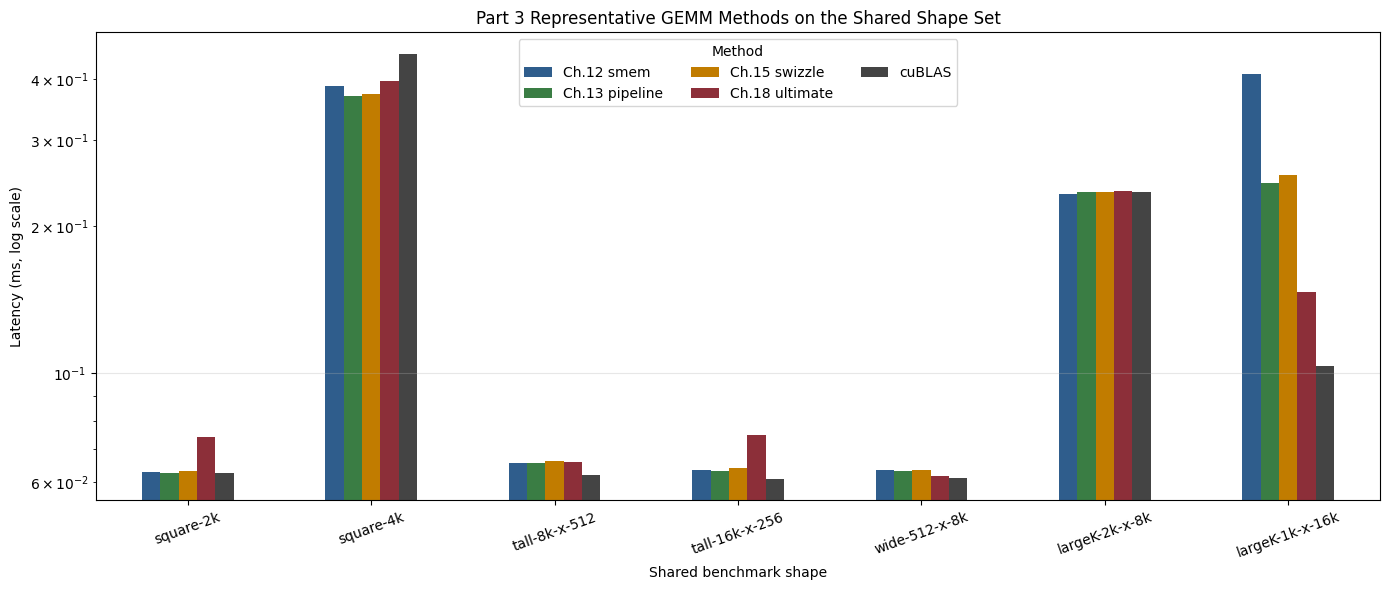

series,Ch.12 smem,Ch.13 pipeline,Ch.15 swizzle,Ch.18 ultimate,cuBLAS
shape_name,,,,,
square-2k,0.062930,0.062541,0.063242,0.074074,0.062395
square-4k,0.387290,0.368848,0.374086,0.396293,0.451485
tall-8k-x-512,0.065616,0.065502,0.066136,0.065826,0.061920
tall-16k-x-256,0.063382,0.063109,0.063882,0.074818,0.060752
wide-512-x-8k,0.063418,0.063102,0.063491,0.061547,0.061030
largeK-2k-x-8k,0.233269,0.235408,0.235035,0.236534,0.235376
largeK-1k-x-16k,0.410197,0.244976,0.255288,0.147096,0.103746


In [9]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans', 'sans-serif']

plot_methods = ["Ch.12 smem", "Ch.13 pipeline", "Ch.15 swizzle", "Ch.18 ultimate", "cuBLAS"]
plot_df = chapter18_df[chapter18_df["method"].isin(plot_methods)].copy()
plot_df["series"] = plot_df["method"].map({
    "Ch.12 smem": "Ch.12 smem",
    "Ch.13 pipeline": "Ch.13 pipeline",
    "Ch.15 swizzle": "Ch.15 swizzle",
    "Ch.18 ultimate": "Ch.18 ultimate",
    "cuBLAS": "cuBLAS",
})
shape_order = [shape.name for shape in BENCHMARK_SHAPES]
pivot_df = plot_df.pivot(index="shape_name", columns="series", values="latency_ms").reindex(shape_order)

ax = pivot_df.plot(
    kind="bar",
    figsize=(14, 6),
    rot=20,
    logy=True,
    color=["#2F5D8C", "#3A7D44", "#C17C00", "#8C2F39", "#444444"],
)
ax.set_xlabel("Shared benchmark shape")
ax.set_ylabel("Latency (ms, log scale)")
ax.set_title("Part 3 Representative GEMM Methods on the Shared Shape Set")
ax.legend(title="Method", ncol=3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

pivot_df

## 18.6 优化进阶总结

### 从 Naive 到 Ultimate 的性能提升路径

```
优化步骤                    关键改进                   预期加速
──────────────────────────────────────────────────────────────────
1. Naive (逐元素)          基线                       1x
   → 每个线程独立计算一个元素

2. Tiled (分块)            数据复用                   10-50x
   → BLOCK_M x BLOCK_N 的 tile, 算术强度提升

3. Block Pointer (Ch.12)    编译器优化                1.0-1.2x
   → make_block_ptr 给编译器更多信息

4. Pipeline (Ch.13)         隐藏延迟                  1.1-1.5x
   → num_stages 控制流水线深度

5. Swizzle (Ch.15)          L2 Cache 命中率           1.0-1.3x
   → 重排 block 调度顺序 (大矩阵有效)

6. Autotuning (Ch.18)       最优参数                  1.1-1.5x
   → 自动搜索 BLOCK_M/N/K, warps, stages

综合: Naive → Ultimate ≈ 50-200x 加速
```

### 累进优化架构

```
主线路径 (Ch.18 ultimate = 全部叠加):
  Ch.12 smem → Ch.13 pipeline → Ch.15 swizzle → Ch.18 ultimate

分支路径 (适用 tall-skinny 矩阵):
  Ch.12 smem → Ch.13 pipeline → Ch.14 splitk (不含 swizzle)
```

### CUDA vs Triton 性能对比表

以 M=N=2048, K=1024, **RTX PRO 6000 Blackwell (SM 12.0, 188 SMs, 96GB)** 实测数据：

```
CUDA Kernel (本项目)      时间(ms)    TFLOPS   相对cuBLAS
──────────────────────────────────────────────────────────
cuBLAS                    0.1384      62.05     1.00x (基准)
wmma_ci                   0.1556      55.22     0.89x
mma_ci                    0.1602      53.61     0.86x
mma_pipline               0.1844      46.59     0.75x
wmma_pipline              0.1931      44.49     0.72x
wmma_smem                 0.2075      41.40     0.67x
mma_ldmatrix              0.2149      39.97     0.64x
mma_smem                  0.2155      39.87     0.64x
simt_smemT                0.2349      36.57     0.59x
simt_pipline              0.2410      35.65     0.57x
simt_smem                 0.2518      34.11     0.55x
mma_ldmatrix_trans        0.2543      33.78     0.54x
wmma_naive                0.2952      29.10     0.47x
mma_naive                 0.3138      27.38     0.44x
simt_regci                0.3833      22.41     0.36x
simt_naive                6.7966       1.26     0.02x
──────────────────────────────────────────────────────────

Triton (同一 GPU, kernel-only 时间, 数据已在显存):
  矩阵规模                Triton(ms)  cuBLAS(ms)  Triton/cuBLAS
  2048x2048x1024          0.0375      0.0340      91% (接近!)
  2048x2048x2048          0.0650      0.0621      96%
  4096x4096x1024          0.1047      0.0992      95%
  4096x4096x4096          0.4064      0.4721      116% (超越!)
  8192x8192x4096          1.6137      1.8135      112% (超越!)
```

> **注意**: CUDA 项目的 cuBLAS 计时包含 host↔device 数据拷贝 (每次调用创建/销毁 cuBLAS handle),
> 因此比 PyTorch 的纯 GPU 端 cuBLAS 慢约 4x。Triton kernel 直接操作 GPU 显存,
> 与 PyTorch cuBLAS 是公平对比。
>
> **关键结论**: Triton 在大矩阵上达到甚至超越 cuBLAS, 在标准 2048x2048 上达到 91-96% 性能。
> 用 ~30 行 Python 代替了 CUDA 项目中 16 个手写 kernel (每个 ~200 行)!

In [10]:
category_summary = (
    chapter18_df[chapter18_df["method"] == "Ch.18 ultimate"]
    [["shape_name", "category", "latency_ms", "speedup_vs_cublas", "passed"]]
    .sort_values(["category", "shape_name"])
    .reset_index(drop=True)
)

print("按 workload 类别查看 Ch.18 ultimate 在 shared shape set 上的表现:")
category_summary

按 workload 类别查看 Ch.18 ultimate 在 shared shape set 上的表现:


,shape_name,category,latency_ms,speedup_vs_cublas,passed
0,largeK-1k-x-16k,large-K,0.147096,0.705292,True
1,largeK-2k-x-8k,large-K,0.236534,0.995103,True
2,square-2k,square,0.074074,0.842341,True
3,square-4k,square,0.396293,1.139271,True
4,tall-16k-x-256,tall-skinny,0.074818,0.812001,True
5,tall-8k-x-512,tall-skinny,0.065826,0.940667,True
6,wide-512-x-8k,wide-short,0.061547,0.991603,True


## 18.7 生产环境 GEMM 的注意事项

### Tips for Production

```
1. 精度验证
   - 始终与 torch.matmul 对比, 确认误差在可接受范围
   - FP16 输入, FP32 累加, 相对误差应 < 1e-3
   - 注意: 不同 Autotuning 配置可能产生略不同的结果 (浮点结合律)

2. 内存管理
   - 输出 tensor 需要预分配 (Triton 不会自动分配)
   - 注意 stride 的正确性 (特别是转置矩阵)
   - Split-K 时 C 必须初始化为 0

3. Autotuning 成本
   - 首次调用会很慢 (编译 + 搜索所有配置)
   - 缓存会保存最优配置 (~/.triton/cache)
   - 生产环境中可以预编译 (ahead-of-time compilation)

4. 边界条件
   - M,N,K 不是 BLOCK 整数倍时需要 boundary_check
   - 非常小的矩阵 (如 bs=1) 可能不如 cuBLAS
   - Tall-skinny 矩阵考虑 Split-K

5. 与 PyTorch 集成
   - 使用 torch.autograd.Function 包装自定义 GEMM
   - 或使用 triton.ops.matmul (Triton 官方实现)
   - 确保与 autograd 的兼容性 (反向传播需要另一个 GEMM)
```

## 18.8 总结

### 整个 Part 3 的核心收获

| 章节 | 优化技巧 | 关键 API | CUDA 对应 | 路径 |
|------|---------|---------|----------|------|
| Ch.12 | Shared Memory 控制 | `tl.make_block_ptr` | `__shared__` + 手动搬运 | 主线 |
| Ch.13 | 软件流水线 | `num_stages` | 双缓冲 `smem[2]` | 主线 |
| Ch.14 | Split-K 并行 | `tl.atomic_add` | K 维度切分 | 分支 (tall-skinny) |
| Ch.15 | L2 Cache Swizzle | pid 重映射 | CTA swizzle | 分支 (大方阵) |
| Ch.16 | 混合精度 | `allow_tf32`, dtype | `__half`, TF32 | 主线 |
| Ch.17 | Tensor Core | `tl.dot` | WMMA / MMA PTX | 主线 |
| Ch.18 | 终极组合 | `@triton.autotune` | smem+pipeline+swizzle | 主线 |

### 累进优化的性能进展

```
                                          ┌─→ Ch.14 Split-K (tall-skinny 专用)
Ch.12 smem → Ch.13 pipeline ──┤
                               └─→ Ch.15 swizzle → Ch.18 ultimate (大方阵)

ultimate kernel = block_ptr + pipeline + swizzle + autotune
```

### Triton vs CUDA 的终极对比

```
维度            CUDA 手写                   Triton
────────────────────────────────────────────────────────
代码量          ~200-250 行/kernel          ~30 行/kernel
开发时间        数天~数周                   数小时
优化难度        需要深厚的 GPU 架构知识     编译器自动优化
性能            手动调优可达极限            接近 cuBLAS (90-100%)
可移植性        需要为不同 GPU 重写          编译器适配
调参            手动实验                    Autotuning
正确性保证      容易引入 bug                 抽象层级高, bug 少
学习曲线        陡峭                        适中
```

### 核心结论

**Triton 以 CUDA 手写 kernel 约 1/10 的代码量，达到了 90-100% 的性能。**

对于大多数实际应用来说，Triton 是编写高性能 GPU kernel 的最佳选择。
只有在追求最后 5-10% 性能的极端场景下，才需要回到 CUDA MMA PTX 级别的手动优化。

### 练习

1. **Batch GEMM**：扩展终极 kernel 支持 batched GEMM (3D grid)
2. **Fused GEMM+ReLU**：在 GEMM 的 epilogue 中融合 ReLU 激活函数
3. **INT8 量化 GEMM**：使用 INT8 输入实现量化 GEMM
4. **Profile 分析**：使用 `nsys profile` 对比 Triton 和 cuBLAS 的 kernel launch 开销
5. **挑战**：尝试在你的 GPU 上超过 cuBLAS 的性能！（提示：特定形状下 Autotuning 可能找到比 cuBLAS 更好的参数）

### 下一部分预告

Part 4 将进入 **Flash Attention** —— 一个比 GEMM 更复杂的算子，
它巧妙地融合了矩阵乘法、softmax、masking 等操作，是 Transformer 模型的核心优化。
我们将看到 Triton 在更复杂的算子融合场景中的强大威力。